### Imports and plotting setting

In [8]:
import numpy as np
from scipy.optimize import fsolve, root

# import predefined functions wich solve the box model
import fct_BoxModel as fbm

import xarray as xr
import pandas as pd
import matplotlib
from matplotlib import cm
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.colors import Normalize
import cv2 as cv

from matplotlib import colors

from cmcrameri import cm as cmcra



matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'

matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

SMALL_SIZE = 12
MEDIUM_SIZE = 14
BIGGER_SIZE = 16

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=128):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

lipari_cut = truncate_colormap(cmcra.lipari, minval=0.15, maxval=1.0, n=128)

### Importing the input dataset

In [9]:
# inputs from mk_input_dataset.ipynb
inputs = xr.open_dataset("model_input_dataset.nc")
index_isf = inputs.Nisf.values
name_isf = inputs.name_isf.values

#outputs
outputs = xr.open_dataset("model_output_dataset.nc")

### Defining the parameters

In [10]:
#PICO parameters
# Reese 2018
C = 1e6 #m^6/s/kg
gammaT = 2e-5 #m/s

#Vertical mixing
# ~Olbers & Hellmer 2010
kappa_diff = 1e-7  # m/s
kappa_conv = 1e-3 # m/s

#Polynia
g = 20

#AABW
C2 = 4e6 #m^6/s/kg

#density
rho_i = 910 #kg/m^3


#creating a dictionary to stock bistable sizes
delta_bistable = {}

### Defining plotting function

In [11]:
# functions to compute the bistable region size

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def bistable_size(bistable,T0_list,T0_ref,Ap_list):
    idx = find_nearest(T0_list,T0_ref)
    bist_arg = np.where(bistable[:,idx].mask == False)[0]
    Apbmin = Ap_list[bist_arg[0]]
    Apbmax = Ap_list[bist_arg[-1]]
    delta_Ap = Apbmax-Apbmin
    return Apbmin, Apbmax, delta_Ap

In [39]:
import imp
imp.reload(fbm)

def solver(guess, guess_0, args, incr_max, sigma, stability, melt_list, m, n):

    nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa,g,frac,depth, C2, T_surf_ref, S_surf_ref, mode = args

    X, info, ier, msg = fsolve(fbm.BoxModel, guess, args=args, full_output=True)

    if ier != 1: #management of non convergence cases
        incr = 0
        while ier != 1 or X[3]<30 or X[1]<30:
            X, info, ier, msg = fsolve(fbm.BoxModel, np.random.normal(guess,0.15), args=args, full_output=True)
            incr += 1
            if incr == incr_max:
                print('no conv', mode,m,n)
                break
    # update initial guess
    if ier == 1:
        guess_next = X
        if m==0:
            guess_0_next = X
        else:
            guess_0_next = guess_0
    else:
        guess_next = guess
        guess_0_next = guess_0
    
    if ier==1:
        sigma[m,n] = fbm.compute_Sigma(X)
        stability[m,n] = fbm.compute_Sigma(X)<0
        if stability[m,n]:
            T,S,melt,q = fbm.PICO(X[1],X[3], nbox, C, gammaT, Ac, frac, depth)
            melt_list[m,n] = fbm.compute_m_avg(melt,frac,nbox)
        else:
            melt_list[m,n] = np.nan
    else:
        stability[m,n] = np.nan
        melt_list[m,n] = np.nan

    return guess_next, guess_0_next

def plot_column():

    Npoint = 70 #Number of points in the figures (total is Npoint**2)

    #WDW temperature
    T0_list = np.linspace(-2.1,2.1,Npoint) # For the x-axis

    for k, index, name in zip(np.arange(len(index_list)),index_list,name_list):
    
        print(name)
    
        stability_d = np.zeros((Npoint,Npoint))
        stability_c = np.zeros((Npoint,Npoint))
    
        melt_d = np.zeros((Npoint,Npoint))
        melt_c = np.zeros((Npoint,Npoint))
    
        sigma_d = np.zeros((Npoint,Npoint))
        sigma_c = np.zeros((Npoint,Npoint))
        
        nbox = int(inputs.Nbox.sel(Nisf=index).values)
        Ac = inputs.Ac.sel(Nisf=index).values #m^2
    
        Omega_ref = np.mean(inputs.Omega.sel(Nisf=index).values)/30/24/3600 * 2/3 #m/s : 2/3 factor to take into account summer
        y_axis = np.logspace(-1,3,Npoint)
        Ap_list = y_axis/Omega_ref/rho_i *1e12/3600/24/365.25 # Polynya extent in m^2
        
        frac = inputs.frac.sel(Nisf=index).values
        depth = inputs.depth.sel(Nisf=index).values
        T_surf_ref = np.mean(inputs.T_surf.sel(Nisf=index).values)
        S_surf_ref = np.mean(inputs.S_surf.sel(Nisf=index).values)
        S0_ref = np.mean(inputs.S0.sel(Nisf=index).values)
    
        # initial guess for the steady stae of the system
        guess_conv_0 = np.array([0,0,35.5,35.5])
        guess_diff_0 = np.array([0,0,35.5,35.5])
        
        for n, T0 in enumerate(T0_list):
    
            guess_conv = guess_conv_0
            guess_diff = guess_diff_0
            
            for m, Ap in enumerate(Ap_list):
                    
                # Solve for diffusive case
                args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_diff,g,frac,depth, C2, T_surf_ref, S_surf_ref, 'diff')
                guess_diff, guess_diff_0 = solver(guess_diff, guess_diff_0, args, 200, sigma_d, stability_d, melt_d, m, n)

                # Solve for diffusive case
                args = (nbox,C,gammaT,Ac,Omega_ref,T0,S0_ref,Ap,kappa_conv,g,frac,depth, C2, T_surf_ref, S_surf_ref, 'conv')
                guess_diff, guess_diff_0 = solver(guess_conv, guess_conv_0, args, 200, sigma_c, stability_c, melt_c, m, n)
    
                
        # show monostable and bistable cases
        stability_map = np.logical_and(stability_c,stability_d)*0 + np.logical_and(stability_c,np.logical_not(stability_d))*(-1) + np.logical_and(np.logical_not(stability_c),stability_d)*1
    
        # show unstable cases 
        stability_map = np.ma.masked_where(np.logical_and(np.logical_not(stability_c),np.logical_not(stability_d)), stability_map)

        # Compute and plot convective basal mass loss
        melt_c = melt_c*12 *rho_i*Ac /1e12 # Gt/y
        ax[k].contourf(T0_list, y_axis, melt_c,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d)
        contour_c = np.ma.masked_where(stability_map !=-1,melt_c)
        cont_c = ax[k].contour(T0_list, y_axis, contour_c, levels_c, colors='whitesmoke', linewidths=1) 

        # Compute and plot diffusive basal mass loss
        melt_d = melt_d*12 *rho_i*Ac /1e12 # Gt/y
        melt_diff = ax[k].contourf(T0_list, y_axis, melt_d,cmap=lipari_cut,vmin=0,vmax=vmax, levels=levels_d) 
        
        # Plot bistable region
        bistable_zone = np.ma.masked_where(np.logical_not(np.logical_and(stability_c,stability_d)),np.logical_and(stability_c,stability_d)*0.25)
        ax[k].contourf(T0_list, y_axis, bistable_zone,cmap='binary',vmin=0,vmax=1,levels=np.linspace(0,1,6))
    
        # Plot transition thresholds     
        if np.max(sigma_d)>0:
            ax[k].contour(T0_list,y_axis,sigma_d,colors='black',levels=0)
        if np.min(sigma_c)<0:
            ax[k].contour(T0_list,y_axis,sigma_c,colors='black',levels=0,linestyles='dashed')
        
        ax[k].set_title(name)
        ax[k].set_yscale('log')
        ax[k].set_xlim((-2.1,2.1))
        
        ax[k].set_ylim((1e-1,1e3)) # same y-axis

        # Want to print y label?
        if print_ylabel:
            ax[k].set_ylabel("Sea-ice prod. "+r'$\Sigma$'+' '+r'$\mathrm{[Gt/y]}$')
        
        if k==kmax:
            ax[k].set_xlabel(r'$T_0$'+' [°C]')
    
        # series of yearly averages 
        T0_series = inputs.T0.sel(Nisf=index).values
        SeaIce_series = inputs.Ap.sel(Nisf=index).groupby('time.year').mean('time').values *rho_i*Omega_ref *24*3600*365.25/1e12 *2/3 
        #2/3 factors to account for summer

        # Scatter plot of realistic forcing values
        ax[k].scatter(T0_series,SeaIce_series,marker='+', c='white', zorder=2) 
        ax[k].scatter(np.mean(T0_series),np.mean(SeaIce_series),facecolors='white',edgecolors='black',marker='d',s=50,linewidths=1, zorder=2) 

        # compute the bistable region size
        Apbmin, Apbmax, delta_Ap = bistable_size(bistable_zone,T0_list,np.mean(T0_series),Ap_list)
        print(delta_Ap*rho_i*Omega_ref*24*3600*365.25/1e12,'Gt/y')
        delta_bistable[index] = delta_Ap*rho_i*Omega_ref*24*3600*365.25/1e12

        # putting label on convective basal loss contour (here because of a matplotlib whim)
        ax[k].clabel(cont_c, fontsize=8)

        # Scatter plot of PICO forcing
        ax[k].scatter(T0_PICO[k],1.75e-1,marker='$\downarrow$',facecolors='white',edgecolors='white', s=150, linewidths=1,zorder=2)

    #add a colorbar
    cbar_ax = fig.add_axes([0.13, bottom_cbar, 0.75, height_cbar])  # [left, bottom, width, height]
    cbar = fig.colorbar(melt_diff, cax=cbar_ax, orientation='horizontal',
                 label='Basal melt rate [Gt/y]')
    # Move ticks and label to the top
    cbar.ax.xaxis.set_ticks_position('top')
    cbar.ax.xaxis.set_label_position('top')



## Plots Figure 3

### Small cavities

Pine Island
no conv conv 0 1
no conv diff 1 1
no conv conv 1 1
no conv conv 2 1
no conv conv 3 1
no conv conv 4 1
no conv conv 5 1
no conv conv 19 1
no conv diff 1 2
no conv conv 1 2
no conv conv 2 2
no conv conv 3 1
no conv conv 4 1
no conv conv 5 1
no conv conv 19 1
no conv diff 1 2
no conv conv 1 2
no conv conv 2 2
no conv conv 3 2
no conv conv 4 2
no conv conv 5 2
no conv conv 6 2
no conv conv 7 2
no conv conv 8 2
no conv conv 9 2
no conv conv 10 2
no conv conv 16 2
no conv conv 17 2
no conv conv 18 2
no conv conv 22 2
no conv conv 0 3
no conv conv 1 3
no conv conv 2 3
no conv conv 3 3
no conv conv 4 3
no conv conv 5 3
no conv conv 6 3
no conv conv 7 3
no conv conv 8 3
no conv conv 9 3
no conv conv 10 3
no conv conv 11 3
no conv conv 12 3
no conv conv 3 2
no conv conv 4 2
no conv conv 5 2
no conv conv 6 2
no conv conv 7 2
no conv conv 8 2
no conv conv 9 2
no conv conv 10 2
no conv conv 16 2
no conv conv 17 2
no conv conv 18 2
no conv conv 22 2
no conv conv 0 3
no conv conv 1 3
no c

KeyboardInterrupt: 

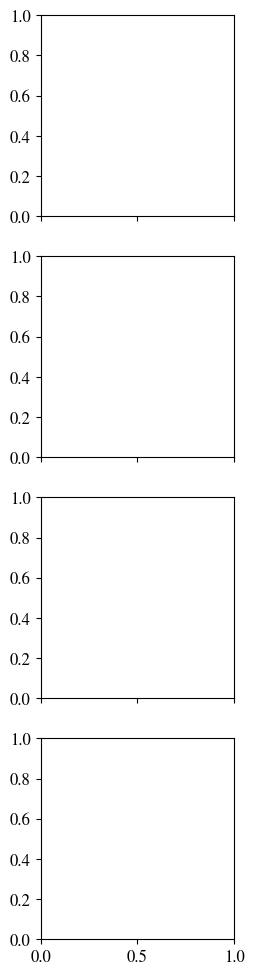

In [40]:
np.random.seed(28) # this random see works well

index_list = [66,52,48,33] #index of plotted cavities
name_list = ['Pine Island', 'Dotson', 'Totten', 'Moscow Univ.'] # name of plotted cavities
T0_PICO = [0.46,0.47,-0.68,-0.73] #PICO temperature forcing
kmax = 4-1 #number of cavities to plt minus one
vmax = 200 #Gt/y #max value for the contour fill
levels_c = np.arange(0,20,1) # convective contours
levels_d = np.arange(0,200,25) # diffusive contours

# some color bar parameters
height_cbar = 0.01
bottom_cbar = 0.91

# print y label ?
print_ylabel = True

fig, ax = plt.subplots(4,1,figsize=(2.5,12),sharex=True, sharey=True,)

plot_column()

plt.savefig('Figures/Figure3/Figure3_small.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Medium Cavities

Amery
332.4259264493727 Gt/y
Riiser-Larsen
71.22680760078657 Gt/y
Roi Baudouin
no conv, diff 0 1


/mnt/c/Users/louis/Documents/GitHub/Low-Dimensionnal-Model-2025/fct_BoxModel.py:44: RuntimeWarning: invalid value encountered in sqrt
  x0 = -g1[0]/(2*C*rho_star*(beta*s-alpha))+np.sqrt((g1[0]/(2*C*rho_star*(beta*s-alpha)))**2-g1[0]*T_st_0/(C*rho_star*(beta*s-alpha)))


25.538668333455753 Gt/y


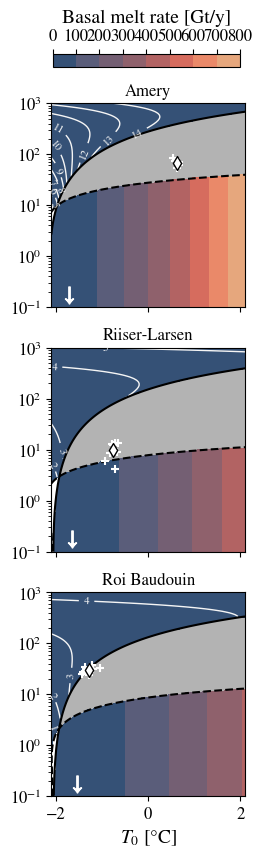

In [7]:
np.random.seed(28) # this random see works well

index_list = [31,43,45]
name_list = ['Amery','Riiser-Larsen', 'Roi Baudouin']
T0_PICO = [-1.72,-1.66,-1.55] #PICO temperature forcing
kmax = 3-1
vmax = 1000 #Gt/y
levels_c = np.arange(0,15,1)
levels_d = np.arange(0,801,100)
height_cbar = 0.01*3/2
bottom_cbar = 0.92

print_ylabel = False

fig, ax = plt.subplots(3,1,figsize=(2.5,9),sharex=True, sharey=True,)

plot_column()

plt.savefig('Figures/Figure3/Figure3_medium.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Large Cavities

Ross
966.8099120408531 Gt/y
Filchner-Ronne
398.3969085233554 Gt/y


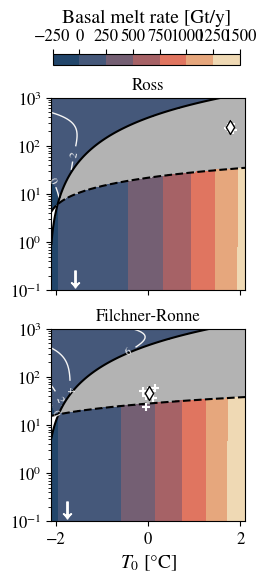

In [8]:
np.random.seed(28) # this random see works well

index_list = [10,11]
name_list = ['Ross','Filchner-Ronne']
T0_PICO = [-1.58,-1.76] #PICO temperature forcing
kmax = 2-1
vmax = 1500 #Gt/y
levels_c = np.arange(0,20,2)
levels_d = np.arange(-250,1501,250)
height_cbar = 0.01*2
bottom_cbar = 0.94

print_ylabel = False

fig, ax = plt.subplots(2,1,figsize=(2.5,5.5),sharex=True, sharey=True,)

plot_column()

plt.savefig('Figures/Figure3/Figure3_large.pdf',format="pdf", bbox_inches = 'tight')
plt.show()

### Relation basal melt and size of the bistable region

In [9]:
delta_bistable_list = []
delta_melt_list = []
for index in list(delta_bistable):
    delta_bistable_list.append(delta_bistable[index])
    
    Ac = inputs.sel(Nisf=index).Ac.values #m^2
    mdiff = outputs.sel(Nisf=index,regime='diff').melt.values*12 #m/y
    mconv = outputs.sel(Nisf=index,regime='conv').melt.values*12 #m/y
    if index==52: #Dotson case: set diff melt to 75Gt/y
        delta_melt_list.append(75-rho_i*Ac*mconv/1e12)
    elif index==33: #Mosc Univ: set conv melt to 7Gt/y
        delta_melt_list.append(rho_i*Ac*mdiff/1e12-7)
    else:
        delta_melt_list.append(rho_i*Ac*(mdiff-mconv)/1e12)

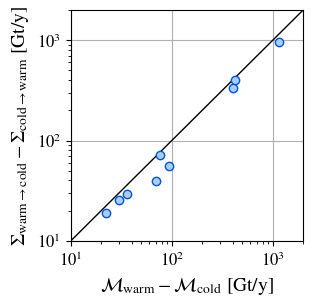

In [10]:
plt.figure(figsize=(3,3))
plt.plot(np.logspace(np.log10(1e1),np.log10(2e3),50),np.logspace(np.log10(1e1),np.log10(2e3),50),c='black',linestyle='solid',linewidth=1)
plt.scatter(delta_melt_list,delta_bistable_list,zorder=2,marker='o',edgecolors='#0055D4', facecolors='#AACCFF')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1e1,2e3)
plt.ylim(1e1,2e3)
plt.xlabel(r'$\mathcal{M}_\mathrm{warm}-\mathcal{M}_\mathrm{cold}$'+' [Gt/y]')
plt.ylabel(r'$\Sigma_\mathrm{warm\to cold} - \Sigma_\mathrm{cold\to warm}$'+' [Gt/y]')
plt.grid()
plt.savefig('Figures/Figure3/bistable_size.pdf',format="pdf", bbox_inches = 'tight')
plt.show()